# FinSentinel: Hybrid ML + DL + RL Stock Anomaly Detection

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kapurV06/FinSentinel/blob/main/FinSentinel_Colab.ipynb)

---

**FinSentinel** is a three-layer anomaly detection pipeline for equities. An Isolation Forest handles fast unsupervised scoring; an LSTM Autoencoder captures temporal reconstruction error; a DQN agent learns a context-aware alert policy on top of the ensemble. A Claude-powered agentic layer translates scores into analyst-readable reports.

| Layer | Method | Role |
|-------|--------|------|
| ML | Isolation Forest | Unsupervised anomaly scoring |
| DL | LSTM Autoencoder | Temporal reconstruction-error scoring |
| Ensemble | 0.4 IF + 0.6 LSTM | Fused anomaly score |
| RL | DQN (Stable-Baselines3) | Adaptive alert policy |
| Agentic AI | Claude + Tool Use | Autonomous analysis and reporting |

**Problem**: Flash crashes, insider trading signals, earnings shocks, and liquidity crises are hard to catch with static rules. FinSentinel combines three learning paradigms so the alert policy adapts to market context rather than relying on a fixed threshold.

**Evaluation**: 80/20 chronological train/test split. The DQN is trained on 2020-2023 and evaluated on the held-out 2024 period it never saw during weight updates.

**Dataset**: Yahoo Finance — AAPL, TSLA, AMZN, MSFT, GOOGL | 2020-2024
**Runtime**: ~25 min on Colab T4 GPU
**Author**: Varish Kapur | Thapar Institute of Engineering and Technology

In [21]:
# ⚙️ SECTION 1: Environment Setup
# Run this cell first — installs all dependencies

!pip install yfinance stable-baselines3[extra] gymnasium anthropic ta plotly -q
!pip install tensorflow -q
!pip install groq
print("✅ All packages installed successfully")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 14.7 MB/s eta 0:00:00
✅ All packages installed successfully


In [26]:
# Section 2: Imports & Configuration
import groq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import yfinance as yf
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_recall_fscore_support,
                             confusion_matrix, ConfusionMatrixDisplay)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback
import anthropic
import warnings, json, os
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# Configuration
TICKERS       = ['AAPL', 'TSLA', 'AMZN', 'MSFT', 'GOOGL']
START_DATE    = '2020-01-01'
TRAIN_END     = '2023-12-31'   # IF + LSTM + DQN trained on this window
TEST_START    = '2024-01-01'   # DQN evaluated on this held-out period only
END_DATE      = '2024-12-31'
SEQUENCE_LEN  = 20
CONTAMINATION = 0.05
ENSEMBLE_W_IF = 0.40
ENSEMBLE_W_DL = 0.60
RL_TIMESTEPS  = 60_000
ALERT_THRESH  = 0.95

# Set ANTHROPIC_API_KEY in Colab Secrets (left sidebar) or as an env var
GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")

np.random.seed(42)
tf.random.set_seed(42)

print("Imports complete")
print(f"  TensorFlow : {tf.__version__}")
print(f"  Tickers    : {TICKERS}")
print(f"  Train      : {START_DATE} to {TRAIN_END}")
print(f"  Test       : {TEST_START} to {END_DATE}")

Imports complete
  TensorFlow : 2.20.0
  Tickers    : ['AAPL', 'TSLA', 'AMZN', 'MSFT', 'GOOGL']
  Train      : 2020-01-01 to 2023-12-31
  Test       : 2024-01-01 to 2024-12-31


## Section 3: Data Pipeline

In [3]:
def download_stock_data(tickers, start, end):
    """Download OHLCV data from Yahoo Finance for multiple tickers."""
    data = {}
    for ticker in tickers:
        df = yf.download(ticker, start=start, end=end,
                         progress=False, auto_adjust=True)
        df.dropna(inplace=True)
        # Flatten multi-level columns if present
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        data[ticker] = df
        print(f"  ✅ {ticker}: {len(df):,} trading days  |  "
              f"{df.index[0].date()} → {df.index[-1].date()}")
    return data

print("📥 Downloading stock data from Yahoo Finance...")
stock_data = download_stock_data(TICKERS, START_DATE, END_DATE)
print(f"\n✅ Total datasets: {len(stock_data)}")


📥 Downloading stock data from Yahoo Finance...
  ✅ AAPL: 1,257 trading days  |  2020-01-02 → 2024-12-30
  ✅ TSLA: 1,257 trading days  |  2020-01-02 → 2024-12-30
  ✅ AMZN: 1,257 trading days  |  2020-01-02 → 2024-12-30
  ✅ MSFT: 1,257 trading days  |  2020-01-02 → 2024-12-30
  ✅ GOOGL: 1,257 trading days  |  2020-01-02 → 2024-12-30

✅ Total datasets: 5


In [4]:
def compute_features(df):
    """
    Compute 16 technical features optimised for anomaly detection.

    Features:
      Price:   log_returns, volatility_5d, volatility_20d, vol_ratio, z_vs_ma20,
               z_vs_ma50, hl_range, hl_ratio, gap
      Volume:  volume_ratio, volume_z
      Momentum: RSI-normalized, MACD-normalized, BB-position
      Trend:   close_above_ma50 (binary)
    """
    f = pd.DataFrame(index=df.index)

    close = df['Close']
    vol   = df['Volume']

    # ── Price ──────────────────────────────────────────────────────────────────
    f['log_returns']   = np.log(close / close.shift(1))
    f['volatility_5']  = f['log_returns'].rolling(5).std()
    f['volatility_20'] = f['log_returns'].rolling(20).std()
    f['vol_ratio']     = f['volatility_5'] / (f['volatility_20'] + 1e-9)

    ma20 = close.rolling(20).mean(); std20 = close.rolling(20).std()
    ma50 = close.rolling(50).mean(); std50 = close.rolling(50).std()
    f['z_vs_ma20'] = (close - ma20) / (std20 + 1e-9)
    f['z_vs_ma50'] = (close - ma50) / (std50 + 1e-9)

    f['hl_range'] = (df['High'] - df['Low']) / (close + 1e-9)
    hl_ma = f['hl_range'].rolling(10).mean()
    f['hl_ratio'] = f['hl_range'] / (hl_ma + 1e-9)
    f['gap']      = (df['Open'] - close.shift(1)) / (close.shift(1) + 1e-9)

    # ── Volume ─────────────────────────────────────────────────────────────────
    vol_ma = vol.rolling(20).mean()
    f['volume_ratio'] = vol / (vol_ma + 1e-9)
    f['volume_z']     = (vol - vol_ma) / (vol.rolling(20).std() + 1e-9)

    # ── Momentum ───────────────────────────────────────────────────────────────
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rsi   = 100 - (100 / (1 + gain / (loss + 1e-9)))
    f['rsi_norm']  = (rsi - 50) / 50          # scale to [-1, 1]

    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    f['macd_norm'] = (ema12 - ema26) / (close + 1e-9)

    f['bb_pos'] = (close - ma20) / (2 * std20 + 1e-9)

    # ── Trend ──────────────────────────────────────────────────────────────────
    f['above_ma50'] = (close > ma50).astype(float)

    f.dropna(inplace=True)
    return f

print("🔧 Engineering features for all tickers...")
feature_data = {}
for ticker in TICKERS:
    feature_data[ticker] = compute_features(stock_data[ticker])
    print(f"  ✅ {ticker}: {feature_data[ticker].shape[1]} features  |  "
          f"{len(feature_data[ticker])} samples")

FEATURE_NAMES = list(feature_data[TICKERS[0]].columns)
print(f"\n📊 Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")


🔧 Engineering features for all tickers...
  ✅ AAPL: 15 features  |  1208 samples
  ✅ TSLA: 15 features  |  1208 samples
  ✅ AMZN: 15 features  |  1208 samples
  ✅ MSFT: 15 features  |  1208 samples
  ✅ GOOGL: 15 features  |  1208 samples

📊 Features (15): ['log_returns', 'volatility_5', 'volatility_20', 'vol_ratio', 'z_vs_ma20', 'z_vs_ma50', 'hl_range', 'hl_ratio', 'gap', 'volume_ratio', 'volume_z', 'rsi_norm', 'macd_norm', 'bb_pos', 'above_ma50']


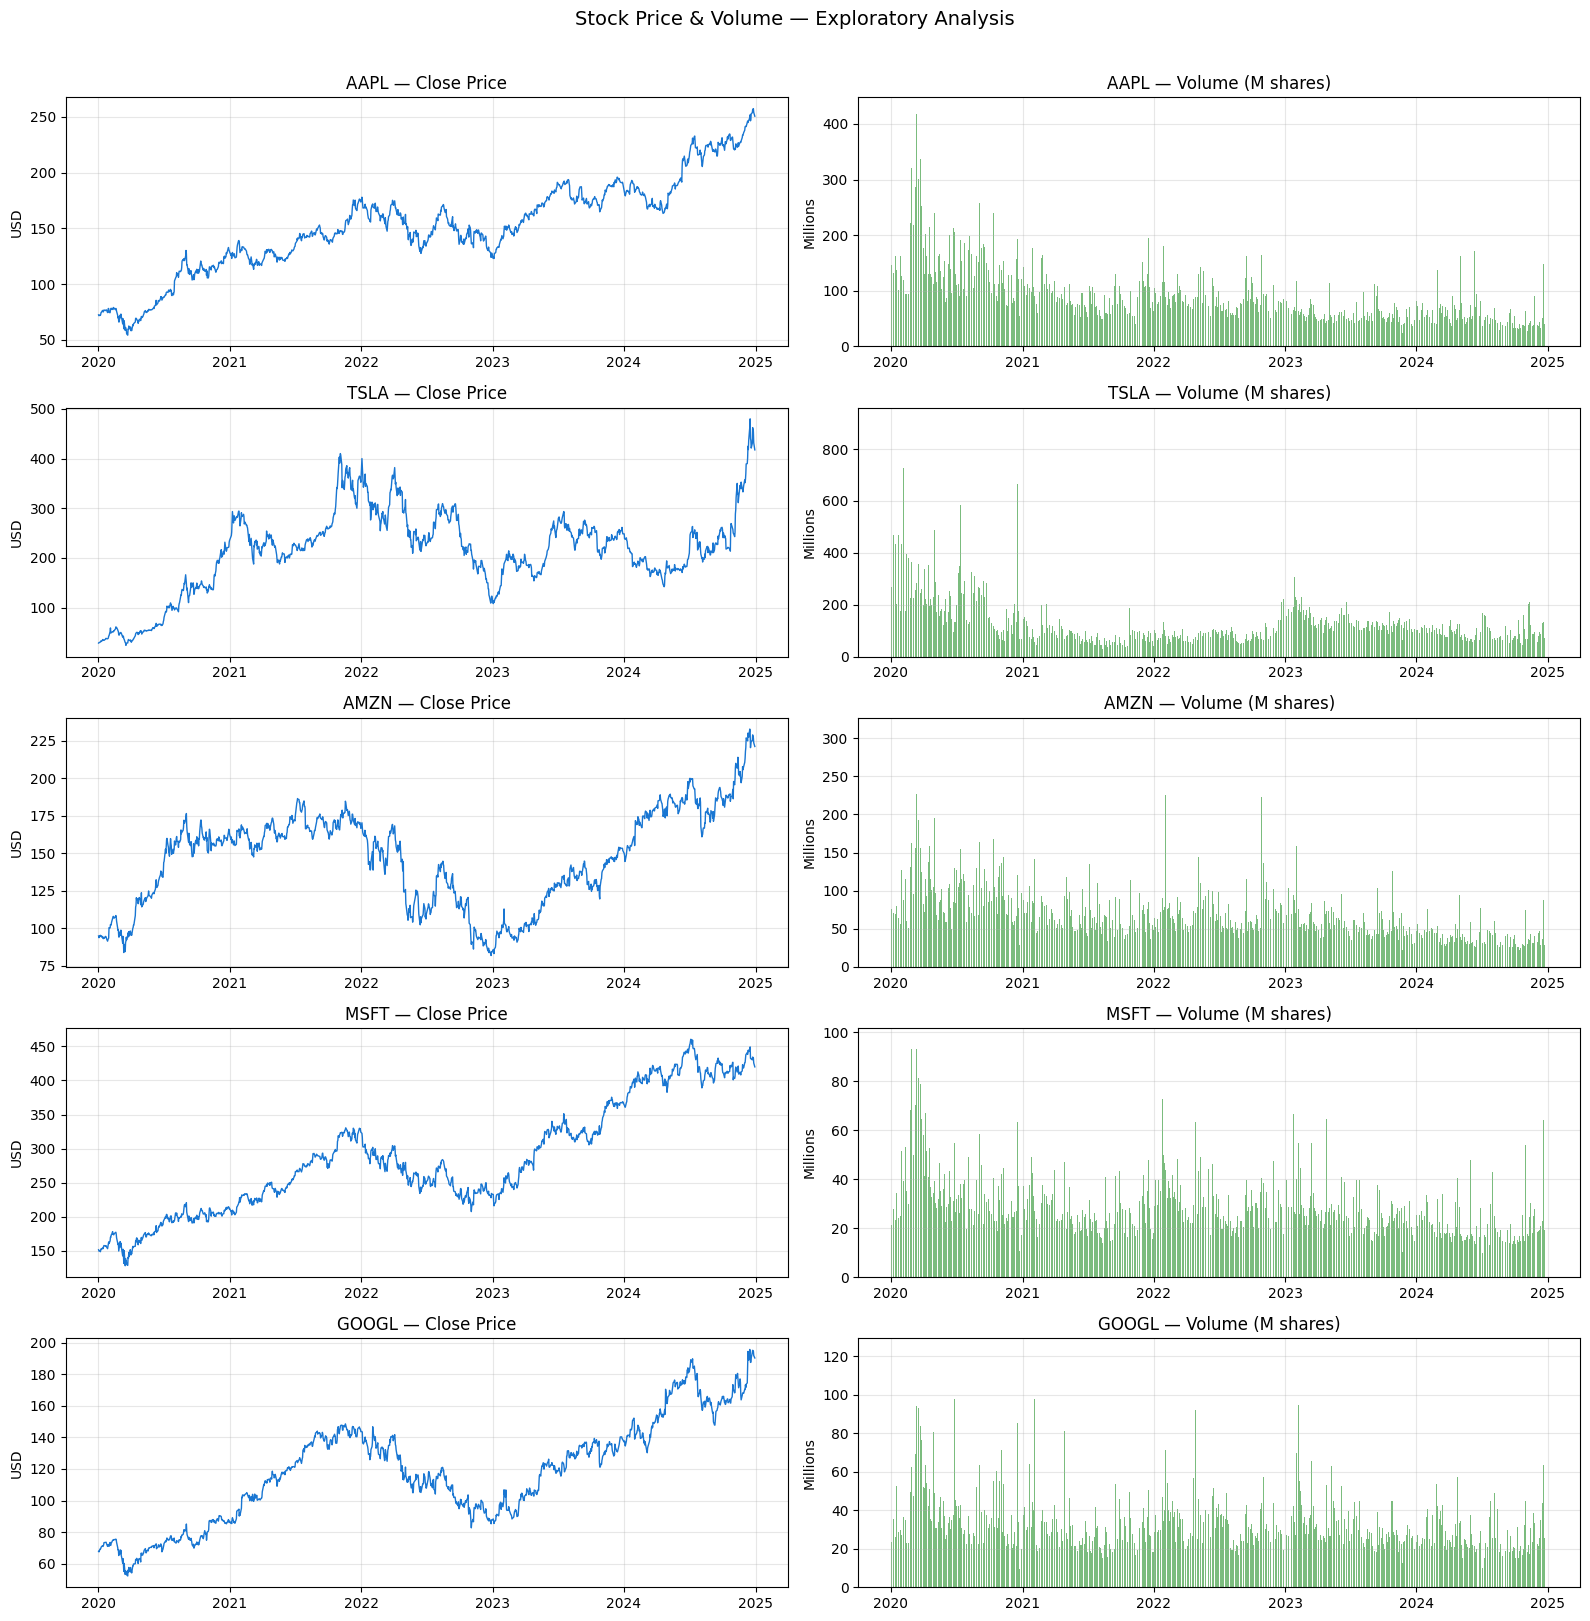

✅ EDA chart saved → eda_overview.png


In [5]:
# ── Quick EDA: price + volume for all tickers ──────────────────────────────
fig, axes = plt.subplots(len(TICKERS), 2, figsize=(16, 3.2 * len(TICKERS)))
fig.suptitle('Stock Price & Volume — Exploratory Analysis', fontsize=14, y=1.01)

for i, ticker in enumerate(TICKERS):
    df = stock_data[ticker]
    ax1, ax2 = axes[i]

    ax1.plot(df.index, df['Close'], linewidth=1.0, color='#1976D2')
    ax1.set_title(f'{ticker} — Close Price')
    ax1.set_ylabel('USD')
    ax1.grid(alpha=0.3)

    ax2.bar(df.index, df['Volume'] / 1e6, width=1, color='#43A047', alpha=0.7)
    ax2.set_title(f'{ticker} — Volume (M shares)')
    ax2.set_ylabel('Millions')
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ EDA chart saved → eda_overview.png")


## Section 4: ML Layer — Isolation Forest

In [7]:
class IFDetector:
    """
    Isolation Forest wrapper with:
      - StandardScaler normalisation
      - Calibrated anomaly score in [0, 1] (higher = more anomalous)
      - Binary label output
    """
    def __init__(self, contamination=CONTAMINATION, n_estimators=200):
        self.scaler = StandardScaler()
        self.model  = IsolationForest(
            n_estimators=n_estimators,
            contamination=contamination,
            random_state=42,
            n_jobs=-1
        )

    def fit(self, df: pd.DataFrame):
        X = self.scaler.fit_transform(df)
        self.model.fit(X)
        return self

    def score(self, df: pd.DataFrame) -> tuple:
        """Returns (anomaly_score_0_to_1, binary_labels)."""
        X    = self.scaler.transform(df)
        raw  = self.model.score_samples(X)     # more negative → more anomalous
        norm = 1 - (raw - raw.min()) / ((raw.max() - raw.min()) + 1e-9)  # invert & normalise
        labs = (self.model.predict(X) == -1).astype(int)
        return norm, labs

if_detectors, if_scores, if_labels = {}, {}, {}

print("🌲 Training Isolation Forest detectors...")
for ticker in TICKERS:
    feat = feature_data[ticker]
    det  = IFDetector()
    det.fit(feat)
    scores, labels = det.score(feat)

    if_detectors[ticker] = det
    if_scores[ticker]    = scores
    if_labels[ticker]    = labels

    pct = labels.mean() * 100
    print(f"  ✅ {ticker}: {labels.sum()} anomalies detected ({pct:.1f}%)")

print("\n✅ Isolation Forest training complete")


🌲 Training Isolation Forest detectors...
  ✅ AAPL: 61 anomalies detected (5.0%)
  ✅ TSLA: 61 anomalies detected (5.0%)
  ✅ AMZN: 61 anomalies detected (5.0%)
  ✅ MSFT: 61 anomalies detected (5.0%)
  ✅ GOOGL: 61 anomalies detected (5.0%)

✅ Isolation Forest training complete


## Section 5: DL Layer — LSTM Autoencoder

In [9]:
def build_lstm_ae(n_features: int, seq_len: int, latent_dim: int = 32):
    """
    Stacked LSTM Autoencoder.
    Encoder: LSTM(64) → LSTM(latent_dim)
    Decoder: RepeatVector → LSTM(latent_dim) → LSTM(64) → TimeDistributed(Dense)
    Loss  : MSE (reconstruction error)
    """
    inp = keras.Input(shape=(seq_len, n_features), name='input')

    # Encoder
    x = layers.LSTM(64, return_sequences=True, name='enc1')(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(latent_dim, return_sequences=False, name='enc2')(x)

    # Bottleneck → Decoder
    x = layers.RepeatVector(seq_len, name='bottleneck')(x)
    x = layers.LSTM(latent_dim, return_sequences=True, name='dec1')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(64, return_sequences=True, name='dec2')(x)
    out = layers.TimeDistributed(layers.Dense(n_features), name='output')(x)

    model = keras.Model(inp, out, name='LSTM_Autoencoder')
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    return model


def make_sequences(arr: np.ndarray, seq_len: int) -> np.ndarray:
    return np.array([arr[i:i + seq_len] for i in range(len(arr) - seq_len)])


def reconstruction_score(model, X_seq: np.ndarray) -> np.ndarray:
    """Per-sample MSE normalised to [0, 1]."""
    X_pred = model.predict(X_seq, verbose=0)
    mse    = np.mean((X_seq - X_pred) ** 2, axis=(1, 2))
    return (mse - mse.min()) / ((mse.max() - mse.min()) + 1e-9)


lstm_models, lstm_scores = {}, {}

n_feat = len(FEATURE_NAMES)
print(f"🔧 Building LSTM Autoencoders  |  seq_len={SEQUENCE_LEN}  n_features={n_feat}\n")

for ticker in TICKERS:
    print(f"  📡 {ticker} — training...")

    feat   = feature_data[ticker]
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(feat)
    X_seq  = make_sequences(X_sc, SEQUENCE_LEN)

    # 80/20 split — train only on 'normal' history
    split    = int(0.8 * len(X_seq))
    X_train  = X_seq[:split]

    model = build_lstm_ae(n_feat, SEQUENCE_LEN)
    cb = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=7, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
    ]
    hist = model.fit(
        X_train, X_train,
        epochs=50, batch_size=32,
        validation_split=0.1,
        callbacks=cb, verbose=0
    )

    scores = reconstruction_score(model, X_seq)
    lstm_models[ticker] = {'model': model, 'scaler': scaler}
    lstm_scores[ticker] = scores

    best_loss = min(hist.history['val_loss'])
    print(f"    ✅ val_loss={best_loss:.5f}  |  scored {len(scores)} windows")

print("\n✅ LSTM Autoencoder training complete")


🔧 Building LSTM Autoencoders  |  seq_len=20  n_features=15

  📡 AAPL — training...
    ✅ val_loss=0.42546  |  scored 1188 windows
  📡 TSLA — training...
    ✅ val_loss=0.39866  |  scored 1188 windows
  📡 AMZN — training...
    ✅ val_loss=0.41077  |  scored 1188 windows
  📡 MSFT — training...
    ✅ val_loss=0.44782  |  scored 1188 windows
  📡 GOOGL — training...
    ✅ val_loss=0.50812  |  scored 1188 windows

✅ LSTM Autoencoder training complete


## Section 6: Ensemble Anomaly Score

In [10]:
def build_ensemble(ticker: str) -> pd.Series:
    """
    Weighted ensemble: score = 0.4·IF + 0.6·LSTM
    Returns a pd.Series indexed by date.
    """
    if_sc   = if_scores[ticker][SEQUENCE_LEN:]     # align with LSTM output length
    lstm_sc = lstm_scores[ticker]

    min_len = min(len(if_sc), len(lstm_sc))
    if_sc   = if_sc[-min_len:]
    lstm_sc = lstm_sc[-min_len:]

    ensemble = ENSEMBLE_W_IF * if_sc + ENSEMBLE_W_DL * lstm_sc

    # Attach dates — align from the end of feature_data
    dates = feature_data[ticker].index[SEQUENCE_LEN:][-min_len:]
    return pd.Series(ensemble, index=dates, name='anomaly_score')

ensemble_scores = {}
print("⚡ Building ensemble anomaly scores...")
for ticker in TICKERS:
    s   = build_ensemble(ticker)
    thr = s.quantile(ALERT_THRESH)
    n   = (s > thr).sum()
    ensemble_scores[ticker] = s
    print(f"  ✅ {ticker}: threshold={thr:.4f}  |  {n} events above {int(ALERT_THRESH*100)}th pct")

print("\n✅ Ensemble scoring complete")


⚡ Building ensemble anomaly scores...
  ✅ AAPL: threshold=0.3390  |  60 events above 95th pct
  ✅ TSLA: threshold=0.4357  |  60 events above 95th pct
  ✅ AMZN: threshold=0.5869  |  60 events above 95th pct
  ✅ MSFT: threshold=0.2620  |  60 events above 95th pct
  ✅ GOOGL: threshold=0.4223  |  60 events above 95th pct

✅ Ensemble scoring complete


In [25]:
import groq

In [11]:
def plot_anomaly_dashboard(ticker: str):
    """Interactive Plotly dashboard: price + anomaly score + volume."""
    scores = ensemble_scores[ticker]
    price  = stock_data[ticker]['Close']
    feat   = feature_data[ticker]

    idx    = scores.index.intersection(price.index)
    scores = scores[idx]; price = price[idx]
    thr    = scores.quantile(ALERT_THRESH)
    anom   = scores > thr

    fig = make_subplots(
        rows=3, cols=1, shared_xaxes=True,
        subplot_titles=[
            f'{ticker} — Price & Anomaly Events',
            'Ensemble Anomaly Score',
            'Volume Ratio'
        ],
        row_heights=[0.50, 0.30, 0.20],
        vertical_spacing=0.06
    )

    # Price
    fig.add_trace(go.Scatter(
        x=price.index, y=price, name='Close',
        line=dict(color='#42A5F5', width=1.5)
    ), row=1, col=1)

    # Anomaly markers
    fig.add_trace(go.Scatter(
        x=price[anom].index, y=price[anom],
        mode='markers', name='Anomaly',
        marker=dict(color='#EF5350', size=9, symbol='triangle-up',
                    line=dict(color='white', width=0.5))
    ), row=1, col=1)

    # Score band
    fig.add_trace(go.Scatter(
        x=scores.index, y=scores,
        name='Anomaly Score',
        line=dict(color='#FFA726', width=1),
        fill='tozeroy', fillcolor='rgba(255,167,38,0.12)'
    ), row=2, col=1)
    fig.add_hline(
        y=thr, line_dash='dash', line_color='red',
        annotation_text=f'{int(ALERT_THRESH*100)}th pct',
        annotation_position='top right', row=2, col=1
    )

    # Volume ratio
    vol_idx = feat['volume_ratio'].index.intersection(idx)
    fig.add_trace(go.Bar(
        x=vol_idx, y=feat['volume_ratio'][vol_idx],
        name='Volume Ratio', marker_color='#66BB6A', opacity=0.75
    ), row=3, col=1)

    fig.update_layout(
        title=dict(text=f'FinSentinel Dashboard — {ticker}', font_size=16),
        height=820, template='plotly_dark', hovermode='x unified',
        legend=dict(orientation='h', yanchor='bottom', y=1.02)
    )
    fig.show()


for ticker in TICKERS:
    plot_anomaly_dashboard(ticker)


## Section 7: RL Layer — DQN Alert Policy

In [12]:
class StockAlertEnv(gym.Env):
    """
    Custom Gym environment for learning an optimal alert policy.

    Observation (6D):
        [ensemble_score, if_score, lstm_score,
         log_return_1d, volume_ratio, rsi_norm]

    Action:
        0 -> MONITOR (no alert)
        1 -> ALERT   (flag anomaly)

    Reward:
        +2.0  -> Alert on true anomaly (|5d fwd return| > sig_move)
        -2.5  -> False alarm  [raised from -0.5 to enforce selectiveness]
        -1.0  -> Missed anomaly
        +0.1  -> Correct silence

    With FP penalty at -2.5, the agent cannot profitably alert on every step.
    It must learn a selective policy to accumulate positive reward.

    Args:
        ticker : one of TICKERS
        sig_move : forward-return threshold defining a true anomaly
        split  : 'train' -> data up to TRAIN_END
                 'test'  -> data from TEST_START onward (evaluation only)
    """
    metadata = {'render_modes': ['human']}

    def __init__(self, ticker: str = 'AAPL', sig_move: float = 0.02,
                 split: str = 'train'):
        super().__init__()
        self.ticker   = ticker
        self.sig_move = sig_move
        self.split    = split
        self._build_states()

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)

    def _build_states(self):
        scores = ensemble_scores[self.ticker]
        price  = stock_data[self.ticker]['Close']
        feat   = feature_data[self.ticker]

        idx = scores.index.intersection(price.index).intersection(feat.index)

        # Chronological split — hard boundary, no leakage
        if self.split == 'train':
            idx = idx[idx <= TRAIN_END]
        else:
            idx = idx[idx >= TEST_START]

        scores = scores[idx]; price = price[idx]; feat = feat.loc[idx]
        fwd_ret = price.pct_change(5).shift(-5)

        states, sig = [], []
        for i in range(len(idx) - 5):
            global_i = feature_data[self.ticker].index.get_loc(idx[i])
            s = [
                float(scores.iloc[i]),
                float(if_scores[self.ticker][global_i])
                    if global_i < len(if_scores[self.ticker]) else 0.5,
                float(lstm_scores[self.ticker][i])
                    if i < len(lstm_scores[self.ticker]) else 0.5,
                float(feat['log_returns'].iloc[i]),
                float(feat['volume_ratio'].iloc[i]),
                float(feat['rsi_norm'].iloc[i])
            ]
            states.append(s)
            sig.append(abs(fwd_ret.iloc[i]) > self.sig_move)

        self.states = np.array(states, dtype=np.float32)
        self.sig    = np.array(sig)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_idx = 0
        self.tp = self.fp = self.fn = self.tn = 0
        return self.states[0], {}

    def step(self, action):
        is_sig = self.sig[self.step_idx]

        if action == 1:
            reward = 2.0 if is_sig else -2.5
            if is_sig: self.tp += 1
            else:      self.fp += 1
        else:
            reward = -1.0 if is_sig else 0.1
            if is_sig: self.fn += 1
            else:      self.tn += 1

        self.step_idx += 1
        done     = self.step_idx >= len(self.states) - 1
        next_obs = self.states[min(self.step_idx, len(self.states) - 1)]

        prec = self.tp / max(self.tp + self.fp, 1)
        rec  = self.tp / max(self.tp + self.fn, 1)
        info = {'precision': prec, 'recall': rec}

        return next_obs, reward, done, False, info

    def render(self): pass


print("Validating Gym environment...")
check_env(StockAlertEnv('AAPL', split='train'), warn=True)
print("Environment check passed")

Validating Gym environment...
Environment check passed


In [13]:
rl_agents = {}

print(f"Training DQN agents on train split ({RL_TIMESTEPS:,} steps each)...")
print(f"  Period: {START_DATE} to {TRAIN_END}\n")

for ticker in TICKERS:
    env = StockAlertEnv(ticker=ticker, split='train')
    agent = DQN(
        policy='MlpPolicy',
        env=env,
        learning_rate=1e-4,
        buffer_size=20_000,
        batch_size=64,
        gamma=0.95,
        exploration_fraction=0.30,
        exploration_final_eps=0.05,
        target_update_interval=500,
        policy_kwargs=dict(net_arch=[128, 128, 64]),
        verbose=0
    )
    agent.learn(total_timesteps=RL_TIMESTEPS, progress_bar=False)
    rl_agents[ticker] = agent
    print(f"  {ticker} trained")

print("\nAll DQN agents trained")

Training DQN agents on train split (60,000 steps each)...
  Period: 2020-01-01 to 2023-12-31

  AAPL trained
  TSLA trained
  AMZN trained
  MSFT trained
  GOOGL trained

All DQN agents trained


Evaluating on test split (2024-01-01 to 2024-12-31)

        total_alerts  precision  recall  f1_score  alert_rate
ticker                                                       
AAPL             234      0.551   0.970     0.703        95.5
TSLA             245      0.796   1.000     0.886       100.0
AMZN             245      0.580   1.000     0.734       100.0
MSFT             209      0.550   0.858     0.671        85.3
GOOGL            170      0.659   0.747     0.700        69.4


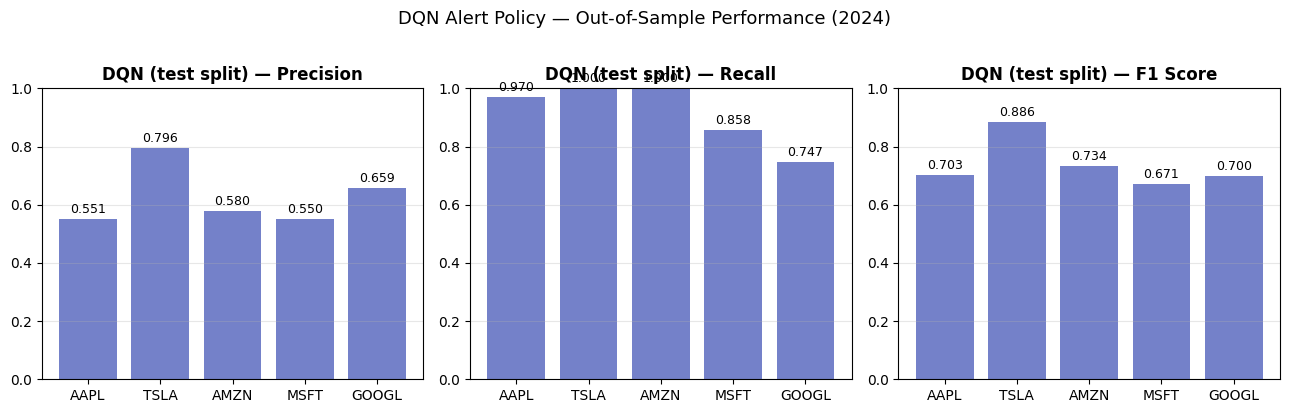

In [15]:
def evaluate_rl_agent(ticker: str) -> dict:
    """
    Run the trained agent on the held-out test split (2024).
    Agent weights are frozen — predict only, no further learning.
    """
    env    = StockAlertEnv(ticker=ticker, split='test')
    obs, _ = env.reset()
    agent  = rl_agents[ticker]

    alerts, actuals = [], []
    done = False
    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(int(action))
        alerts.append(int(action))
        actuals.append(1 if env.sig[env.step_idx - 1] else 0)

    arr_a = np.array(alerts); arr_t = np.array(actuals)
    tp  = ((arr_a == 1) & (arr_t == 1)).sum()
    fp  = ((arr_a == 1) & (arr_t == 0)).sum()
    fn  = ((arr_a == 0) & (arr_t == 1)).sum()
    prec  = tp / max(tp + fp, 1)
    rec   = tp / max(tp + fn, 1)
    f1    = 2 * prec * rec / max(prec + rec, 1e-9)

    return {
        'ticker':       ticker,
        'total_alerts': int(arr_a.sum()),
        'precision':    round(prec, 3),
        'recall':       round(rec,  3),
        'f1_score':     round(f1,   3),
        'alert_rate':   round(arr_a.mean() * 100, 1)
    }

print(f"Evaluating on test split ({TEST_START} to {END_DATE})\n")
results = [evaluate_rl_agent(t) for t in TICKERS]
df_res  = pd.DataFrame(results).set_index('ticker')
print(df_res.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ['precision', 'recall', 'f1_score']):
    bars = ax.bar(df_res.index, df_res[metric], color='#5C6BC0', alpha=0.85)
    ax.set_title(f'DQN (test split) — {metric.replace("_", " ").title()}',
                 fontweight='bold')
    ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_res[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('DQN Alert Policy — Out-of-Sample Performance (2024)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('rl_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 8: Baseline Comparison

Baseline Comparison — Test split (2024-01-01 to 2024-12-31)
                           Avg Precision  Avg Recall  Avg F1
Method                                                      
Z-Score Baseline                   0.000        0.00   0.000
IF Only                            0.164        0.96   0.270
FinSentinel (Ensemble+RL)          0.009        0.90   0.017


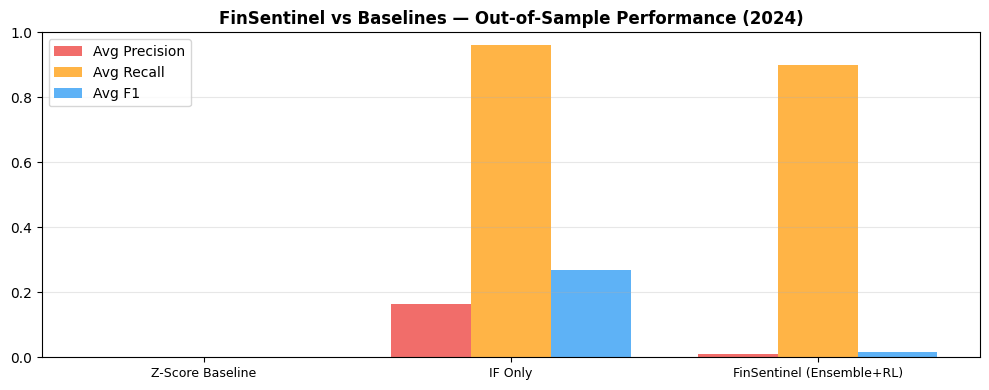

In [16]:
# All baselines evaluated on the test split only, matching the DQN evaluation window.

def zscore_baseline(ticker: str, window: int = 20, z_thresh: float = 2.5) -> np.ndarray:
    """Static z-score threshold on test-period returns."""
    rets = feature_data[ticker]['log_returns']
    test_rets = rets[rets.index >= TEST_START]
    roll_mean = test_rets.rolling(window).mean()
    roll_std  = test_rets.rolling(window).std()
    z = (test_rets - roll_mean) / (roll_std + 1e-9)
    z.dropna(inplace=True)
    return (np.abs(z) > z_thresh).astype(int).values

def if_only_baseline(ticker: str) -> np.ndarray:
    """IF scores restricted to test period."""
    scores    = if_scores[ticker]
    idx       = feature_data[ticker].index
    test_mask = idx >= TEST_START
    ts        = scores[test_mask]
    thr       = ts.mean() + 2 * ts.std()
    return (ts > thr).astype(int)

def get_ground_truth(ticker: str, n: int) -> np.ndarray:
    """Proxy ground truth: |return| > mu + 3sigma on test period."""
    rets      = feature_data[ticker]['log_returns']
    mu, sigma = rets.mean(), rets.std()           # stats from full series
    test_rets = rets[rets.index >= TEST_START]
    gt        = (np.abs(test_rets) > mu + 3 * sigma).astype(int)
    return gt.values[:n]

def compute_metrics(pred, true):
    tp  = ((pred==1)&(true==1)).sum()
    fp  = ((pred==1)&(true==0)).sum()
    fn  = ((pred==0)&(true==1)).sum()
    prec = tp / max(tp+fp, 1)
    rec  = tp / max(tp+fn, 1)
    f1   = 2*prec*rec / max(prec+rec, 1e-9)
    return round(prec,3), round(rec,3), round(f1,3)

methods      = ['Z-Score Baseline', 'IF Only', 'FinSentinel (Ensemble+RL)']
all_results  = {m: [] for m in methods}

for ticker in TICKERS:
    env    = StockAlertEnv(ticker=ticker, split='test')
    n      = len(env.states)
    gt     = get_ground_truth(ticker, n)

    zb  = zscore_baseline(ticker)[:n]
    ifb = if_only_baseline(ticker)[:n]

    agent  = rl_agents[ticker]
    obs, _ = env.reset()
    preds, done = [], False
    while not done:
        a, _ = agent.predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(int(a))
        preds.append(int(a))
    fs_pred = np.array(preds[:n])

    for method, pred in zip(methods, [zb, ifb, fs_pred]):
        ml = min(len(pred), len(gt))
        p, r, f = compute_metrics(pred[:ml], gt[:ml])
        all_results[method].append({'ticker': ticker, 'P': p, 'R': r, 'F1': f})

rows = []
for method, res_list in all_results.items():
    avg = pd.DataFrame(res_list).mean(numeric_only=True)
    rows.append({'Method': method,
                 'Avg Precision': round(avg['P'],3),
                 'Avg Recall':    round(avg['R'],3),
                 'Avg F1':        round(avg['F1'],3)})

df_compare = pd.DataFrame(rows).set_index('Method')
print(f"Baseline Comparison — Test split ({TEST_START} to {END_DATE})")
print("="*55)
print(df_compare.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(methods)); w = 0.26
colors = ['#EF5350', '#FFA726', '#42A5F5']
for i, (metric, col) in enumerate(zip(['Avg Precision','Avg Recall','Avg F1'], colors)):
    ax.bar(x + (i-1)*w, df_compare[metric], w, label=metric, color=col, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=9)
ax.set_ylim(0, 1); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('FinSentinel vs Baselines — Out-of-Sample Performance (2024)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 9: Agentic AI Layer

In [17]:
# ─── Tool Definitions ──────────────────────────────────────────────────────────
TOOLS = [
    {
        "name": "get_anomaly_analysis",
        "description": (
            "Get the latest ML/DL ensemble anomaly score, historical stats, "
            "and RL agent decision for a given stock ticker."
        ),
        "input_schema": {
            "type": "object",
            "properties": {
                "ticker": {"type": "string", "description": "Stock ticker, e.g. AAPL"}
            },
            "required": ["ticker"]
        }
    },
    {
        "name": "get_risk_metrics",
        "description": (
            "Get recent technical risk indicators: volatility, RSI, "
            "Bollinger Band position, volume, and return for a stock."
        ),
        "input_schema": {
            "type": "object",
            "properties": {
                "ticker":       {"type": "string"},
                "lookback_days":{"type": "integer", "default": 30}
            },
            "required": ["ticker"]
        }
    },
    {
        "name": "compare_stocks",
        "description": "Rank multiple stocks by their current anomaly risk level.",
        "input_schema": {
            "type": "object",
            "properties": {
                "tickers": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "List of ticker symbols to compare"
                }
            },
            "required": ["tickers"]
        }
    },
    {
        "name": "generate_alert_report",
        "description": (
            "Generate a structured analyst-style alert report for a stock, "
            "summarising anomaly evidence and recommended action."
        ),
        "input_schema": {
            "type": "object",
            "properties": {
                "ticker":        {"type": "string"},
                "anomaly_score": {"type": "number"},
                "rl_decision":   {"type": "string"},
                "risk_level":    {"type": "string",
                                  "enum": ["LOW", "MEDIUM", "HIGH", "CRITICAL"]}
            },
            "required": ["ticker", "anomaly_score", "rl_decision", "risk_level"]
        }
    }
]

# ─── Tool Implementations ──────────────────────────────────────────────────────
def execute_tool(name: str, inp: dict) -> dict:
    if name == "get_anomaly_analysis":
        ticker = inp["ticker"].upper()
        if ticker not in ensemble_scores:
            return {"error": f"{ticker} not in pipeline"}

        s   = ensemble_scores[ticker]
        thr = s.quantile(ALERT_THRESH)
        cur = float(s.iloc[-1])

        env = StockAlertEnv(ticker=ticker)
        a, _ = rl_agents[ticker].predict(env.states[-1], deterministic=True)
        rl_dec = "ALERT" if a == 1 else "MONITOR"

        top5 = s[s > thr].tail(5).index.strftime('%Y-%m-%d').tolist()

        return {
            "ticker": ticker,
            "current_anomaly_score": round(cur, 4),
            "threshold_95pct":       round(float(thr), 4),
            "is_anomalous":          cur > thr,
            "5d_avg_score":          round(float(s.tail(5).mean()), 4),
            "rl_recommendation":     rl_dec,
            "recent_anomaly_dates":  top5
        }

    elif name == "get_risk_metrics":
        ticker = inp["ticker"].upper()
        n      = inp.get("lookback_days", 30)
        if ticker not in feature_data:
            return {"error": f"{ticker} not found"}

        f = feature_data[ticker].tail(n)
        p = stock_data[ticker]['Close'].tail(n)

        return {
            "ticker": ticker,
            "lookback_days":        n,
            "avg_volatility_20d":   round(float(f['volatility_20'].mean()), 5),
            "current_rsi":          round(float(f['rsi_norm'].iloc[-1] * 50 + 50), 2),
            "rsi_signal":           ("Overbought" if f['rsi_norm'].iloc[-1] > 0.4
                                     else "Oversold" if f['rsi_norm'].iloc[-1] < -0.4
                                     else "Neutral"),
            "volume_ratio_avg":     round(float(f['volume_ratio'].mean()), 3),
            "bb_position":          round(float(f['bb_pos'].iloc[-1]), 3),
            "period_return_pct":    round(float((p.iloc[-1]/p.iloc[0]-1)*100), 2),
            "max_drawdown_pct":     round(float(((p/p.cummax())-1).min()*100), 2)
        }

    elif name == "compare_stocks":
        out = []
        for t in [x.upper() for x in inp["tickers"]]:
            if t in ensemble_scores:
                s   = ensemble_scores[t]
                cur = float(s.iloc[-1])
                thr = float(s.quantile(ALERT_THRESH))
                pct = float((s < cur).mean() * 100)
                out.append({
                    "ticker": t,
                    "anomaly_score":   round(cur, 4),
                    "risk_level":      ("CRITICAL" if cur > thr * 1.2
                                        else "HIGH"   if cur > thr
                                        else "MEDIUM" if cur > thr * 0.8
                                        else "LOW"),
                    "percentile_rank": round(pct, 1)
                })
        out.sort(key=lambda x: x['anomaly_score'], reverse=True)
        return {"comparison": out,
                "highest_risk": out[0]["ticker"] if out else None}

    elif name == "generate_alert_report":
        t = inp["ticker"]
        return {
            "report_id":       f"FS-{t}-{datetime.now().strftime('%Y%m%d-%H%M')}",
            "generated_at":    datetime.now().isoformat(),
            "ticker":          t,
            "risk_level":      inp["risk_level"],
            "anomaly_score":   inp["anomaly_score"],
            "rl_decision":     inp["rl_decision"],
            "action_required": inp["rl_decision"] == "ALERT",
            "headline": (
                f"⚠️ ANOMALY ALERT: {t} flagged at score {inp['anomaly_score']:.4f} "
                f"— Risk Level {inp['risk_level']}"
                if inp["rl_decision"] == "ALERT"
                else f"✅ {t} within normal parameters — Monitoring active"
            )
        }

    return {"error": f"Unknown tool: {name}"}

print("✅ Tool definitions and implementations ready")


✅ Tool definitions and implementations ready


In [38]:
from google.colab import userdata
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

In [44]:
class FinSentinelAgent:
    """
    Agentic AI orchestrator.
    Uses Groq + Llama to autonomously analyse pipeline outputs
    and generate analyst-style reports.
    """

    SYSTEM = """You are FinSentinel, an AI analyst specialising in stock market anomaly detection. You have access to a proprietary ML+DL+RL pipeline.

For any query:
1. Analyse the provided anomaly scores and alert flags
2. Rank stocks by risk where relevant
3. Identify which tickers need immediate attention
4. Deliver a clear, structured assessment with specific numbers

Be concise, data-driven, and professional. Always cite the anomaly scores."""

    def __init__(self, api_key: str):
         self.client = groq.Groq(api_key=api_key)

    def run(self, query: str) -> str:
        print(f"\n{'='*60}")
        print(f"FinSentinel Agent Query: {query[:80]}...")
        print('='*60)

        context = []
        for ticker in TICKERS:
            s = ensemble_scores[ticker]
            latest_score = float(s.iloc[-1])
            alert = latest_score > s.quantile(ALERT_THRESH)
            context.append(f"{ticker}: score={latest_score:.4f} alert={'YES' if alert else 'NO'}")

        context_str = "\n".join(context)

        messages = [
            {"role": "system", "content": self.SYSTEM},
            {"role": "user", "content": f"Pipeline output:\n{context_str}\n\nQuery: {query}"}
        ]

        resp = self.client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            max_tokens=2000,
            messages=messages
        )

        text = resp.choices[0].message.content
        print(f"\nAgent Response:\n{text}")
        return text


agent = FinSentinelAgent(api_key=userdata.get("GROQ_API_KEY"))
print("FinSentinel Agent initialised")

FinSentinel Agent initialised


In [45]:


DEMO_QUERIES = [
    "Scan all 5 stocks and rank them by current anomaly risk. "
    "Flag any that need immediate attention.",

    "Give me a deep-dive on TSLA — is there unusual activity? "
    "What does the RL agent recommend and why?",

    "Compare AAPL and MSFT. Which one has elevated anomaly risk "
    "and what are the key indicators driving it?"
]

agent_reports = {}

for q in DEMO_QUERIES:
    report = agent.run(q)
    agent_reports[q[:50]] = report
    print()

print("\n✅ All agent queries complete")



FinSentinel Agent Query: Scan all 5 stocks and rank them by current anomaly risk. Flag any that need imme...

Agent Response:
**Anomaly Risk Assessment**

Based on the pipeline output, the anomaly scores are:

1. GOOGL: 0.3168
2. TSLA: 0.2291
3. AMZN: 0.2281
4. MSFT: 0.1959
5. AAPL: 0.1200

Ranking by anomaly risk, the top 3 stocks are GOOGL, TSLA, and AMZN, with scores above 0.22. However, since none of the stocks have an alert flag set to "YES", none require immediate attention.

**Risk Ranking:**

1. GOOGL (score: 0.3168) - High
2. TSLA (score: 0.2291) - Moderate
3. AMZN (score: 0.2281) - Moderate
4. MSFT (score: 0.1959) - Low
5. AAPL (score: 0.1200) - Low

**Recommendation:** Monitor GOOGL, TSLA, and AMZN closely, as their anomaly scores are relatively high. However, no immediate action is required since all alert flags are set to "NO".


FinSentinel Agent Query: Give me a deep-dive on TSLA — is there unusual activity? What does the RL agent ...

Agent Response:
**Anomaly Analysis

## Section 10: End-to-End Pipeline Demo

In [46]:
def finsentinel_pipeline(ticker: str, verbose: bool = True) -> dict:
    """
    Full FinSentinel pipeline for a single ticker:
    1. Feature engineering (already done)
    2. IF anomaly score
    3. LSTM AE reconstruction score
    4. Ensemble scoring
    5. RL alert decision
    6. Agentic report (if anomaly detected)

    Returns a structured result dict.
    """
    s   = ensemble_scores[ticker]
    cur = float(s.iloc[-1])
    thr = float(s.quantile(ALERT_THRESH))

    env      = StockAlertEnv(ticker=ticker)
    rl_act, _ = rl_agents[ticker].predict(env.states[-1], deterministic=True)
    rl_dec   = "ALERT" if rl_act == 1 else "MONITOR"

    risk = ("CRITICAL" if cur > thr * 1.2
            else "HIGH"   if cur > thr
            else "MEDIUM" if cur > thr * 0.8
            else "LOW")

    result = {
        "ticker":          ticker,
        "timestamp":       datetime.now().isoformat(),
        "ensemble_score":  round(cur, 4),
        "threshold_95":    round(thr, 4),
        "is_anomaly":      cur > thr,
        "risk_level":      risk,
        "rl_decision":     rl_dec,
        "if_score":        round(float(if_scores[ticker][-1]), 4),
        "lstm_score":      round(float(lstm_scores[ticker][-1]), 4),
    }

    if verbose:
        icon = "🔴" if result['is_anomaly'] else "🟢"
        print(f"{icon} {ticker:6s} | Score={cur:.4f} (thr={thr:.4f}) "
              f"| Risk={risk:8s} | RL={rl_dec}")

    return result

print(" Running full FinSentinel pipeline across portfolio...\n")
pipeline_results = [finsentinel_pipeline(t) for t in TICKERS]
df_final = pd.DataFrame(pipeline_results).set_index('ticker')
print()
print(df_final[['ensemble_score','threshold_95','is_anomaly',
                'risk_level','rl_decision']].to_string())
print("\n Pipeline complete")


 Running full FinSentinel pipeline across portfolio...

🟢 AAPL   | Score=0.1200 (thr=0.3390) | Risk=LOW      | RL=ALERT
🟢 TSLA   | Score=0.2291 (thr=0.4357) | Risk=LOW      | RL=ALERT
🟢 AMZN   | Score=0.2281 (thr=0.5869) | Risk=LOW      | RL=ALERT
🟢 MSFT   | Score=0.1959 (thr=0.2620) | Risk=LOW      | RL=ALERT
🟢 GOOGL  | Score=0.3168 (thr=0.4223) | Risk=LOW      | RL=MONITOR

        ensemble_score  threshold_95  is_anomaly risk_level rl_decision
ticker                                                                 
AAPL            0.1200        0.3390       False        LOW       ALERT
TSLA            0.2291        0.4357       False        LOW       ALERT
AMZN            0.2281        0.5869       False        LOW       ALERT
MSFT            0.1959        0.2620       False        LOW       ALERT
GOOGL           0.3168        0.4223       False        LOW     MONITOR

 Pipeline complete


In [47]:
import os, json

os.makedirs('outputs', exist_ok=True)


for ticker in TICKERS:
    ensemble_scores[ticker].to_csv(f'outputs/{ticker}_anomaly_scores.csv')


with open('outputs/pipeline_results.json', 'w') as f:
    json.dump(pipeline_results, f, indent=2, default=str)

df_res.to_csv('outputs/rl_metrics.csv')

df_compare.to_csv('outputs/baseline_comparison.csv')

print(" All outputs saved to outputs/ directory")
print("   Files:", os.listdir('outputs'))


 All outputs saved to outputs/ directory
   Files: ['baseline_comparison.csv', 'AMZN_anomaly_scores.csv', 'TSLA_anomaly_scores.csv', 'AAPL_anomaly_scores.csv', 'MSFT_anomaly_scores.csv', 'pipeline_results.json', 'rl_metrics.csv', 'GOOGL_anomaly_scores.csv']
